# Week 1 hands-on: an autograd engine from scratch

*Generative AI from First Principles* · [course page](https://mathrulestheworld.github.io/genai-first-principles/)

Every model in this course is trained by gradient descent, and every gradient is computed by **reverse-mode automatic differentiation**. This notebook works through that machinery, written from scratch in about 300 lines of NumPy ([`tinylm/autograd.py`](../tinylm/autograd.py)), and then uses it to train two classifiers.

**Part A, the live walkthrough** (the lecture's twenty-minute hands-on segment):

1. What a tensor holds, and a small forward computation.
2. Walking the graph backwards; a value used twice.
3. Gradient shapes: a matrix product, a reduction, and a broadcast bias.
4. Checking a derivative with finite differences.
5. One gradient step: autograd computes gradients, the optimizer updates parameters.

**Part B, beyond the lecture:**

6. Why reverse mode is cheap: the gradient costs a constant multiple of the function.
7. Checking gradients: the choice of step size, and a comparison with PyTorch.
8. Logistic regression on a two-class problem.
9. A two-layer network on the same problem, and then on handwritten digits.

From Week 2 on we use PyTorch, whose autograd does exactly what this engine does, on GPUs and at scale. The point of this week is that nothing about it is magic.

In [1]:
import sys, time, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # use the repository's tinylm without installing it

import numpy as np
import matplotlib.pyplot as plt
from tinylm.autograd import Tensor, cross_entropy, binary_cross_entropy_with_logits, gradcheck, numerical_grad, topological_order
from tinylm.nn import Linear, MLP
from tinylm.optim import SGD, Adam

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

# Part A: the live walkthrough

## 1. What a tensor holds

A `Tensor` wraps a NumPy array, its **data**. If gradients should flow to it (`requires_grad=True`), then after a backward pass it also holds a **gradient** of the same shape. A tensor produced by an operation remembers two more things: its **parents**, the tensors it was computed from, and a **backward rule** that turns a gradient for the output into gradients for the parents.

Below is a small forward computation: four examples with three features each, a linear layer with two outputs, and a scalar loss, the mean of the squared outputs.

In [2]:
X = Tensor(rng.normal(size=(4, 3)))                       # inputs: 4 examples, 3 features (no gradient needed)
W = Tensor(rng.normal(size=(3, 2)), requires_grad=True)   # parameters
b = Tensor(np.array([0.5, -0.5]), requires_grad=True)

Z = X @ W + b            # (4, 3) @ (3, 2) -> (4, 2); b has shape (2,) and is broadcast across the 4 rows
L = (Z ** 2).mean()      # one number (the engine computes a mean as a sum divided by a count)

def describe(t, name):
    parents = ", ".join(p.op or "leaf" for p in t.parents) or "none"
    print(f"{name}: shape {str(t.shape):7s} op {t.op or 'leaf':5s} parents: {parents:12s} grad: {t.grad}")

for t, name in [(X, "X"), (W, "W"), (b, "b"), (Z, "Z"), (L, "L")]:
    describe(t, name)
print("\nL =", L.item())

X: shape (4, 3)  op leaf  parents: none         grad: None
W: shape (3, 2)  op leaf  parents: none         grad: None
b: shape (2,)    op leaf  parents: none         grad: None
Z: shape (4, 2)  op +     parents: @, leaf      grad: None
L: shape ()      op /     parents: sum, leaf    grad: None

L = 3.913178994326357


## 2. Walking the graph backwards

`L.backward()` visits the graph in reverse topological order, so that every tensor is processed after all the tensors that use it. At each node it applies the node's backward rule, the chain rule for that one operation, and passes the results to the parents. Gradients are kept only at the leaves, here `W` and `b`, as in PyTorch. The whole loop is a dozen lines at the end of the `Tensor` class in `tinylm/autograd.py`.

In [3]:
L.backward()
names = {W: "W", b: "b"}                          # the leaves, by name
print("order of the backward pass:", " -> ".join(names.get(n, n.op) for n in reversed(topological_order(L))))
print("W.grad =\n", W.grad)
print("b.grad =", b.grad)

order of the backward pass: / -> sum -> **2 -> + -> b -> @ -> W
W.grad =
 [[-2.3929 -0.5055]
 [-1.5401 -0.278 ]
 [ 0.6985  0.0997]]
b.grad = [ 0.4044 -0.4786]


### A value used twice

When a tensor feeds into several operations, each use sends back its own contribution, and the contributions **add**. This is the multivariable chain rule. Take the scalar function $f(x, y) = \log(1 + e^{xy}) + x^2$, in which $x$ is used twice:
$$\frac{\partial f}{\partial x} = \underbrace{y\,\sigma(xy)}_{\text{through } \log(1+e^{xy})} + \underbrace{2x}_{\text{through } x^2}, \qquad \sigma(t) = \frac{1}{1 + e^{-t}}.$$

In [4]:
x = Tensor(1.5, requires_grad=True)
y = Tensor(-0.5, requires_grad=True)
f = (1 + (x * y).exp()).log() + x ** 2
f.backward()

def show_graph(node, depth=0, seen=None):
    seen = set() if seen is None else seen
    label = node.op or ("x" if node is x else "y" if node is y else "const")
    print("  " * depth + f"{label:8s} value = {node.data: .4f}")
    if node not in seen:
        seen.add(node)
        for p in node.parents:
            show_graph(p, depth + 1, seen)

show_graph(f)
s = 1 / (1 + np.exp(-x.data * y.data))                 # sigmoid(xy), the derivative of log(1 + e^t) at t = xy
print(f"\ncontribution through log(1 + e^(xy)): {s * y.data: .6f}")
print(f"contribution through x**2:            {2 * x.data: .6f}")
print(f"sum, by hand:                         {s * y.data + 2 * x.data: .6f}")
print(f"autograd:  df/dx = {x.grad:.6f}   df/dy = {y.grad:.6f} (by hand {s * x.data:.6f})")

+        value =  2.6369
  log      value =  0.3869
    +        value =  1.4724
      exp      value =  0.4724
        *        value = -0.7500
          x        value =  1.5000
          y        value = -0.5000
      const    value =  1.0000
  **2      value =  2.2500
    x        value =  1.5000

contribution through log(1 + e^(xy)): -0.160411
contribution through x**2:             3.000000
sum, by hand:                          2.839589
autograd:  df/dx = 2.839589   df/dy = 0.481232 (by hand 0.481232)


## 3. Gradient shapes

The gradient of a scalar loss with respect to a tensor has the **same shape as the tensor**. For the linear layer, write $G = \partial L/\partial Z$, a $4\times 2$ array; here $G = 2Z/8$, since $L$ averages eight squares. The backward rules of the three operations are:

| Forward | Backward |
|---|---|
| $Z = XW$ (matrix product) | $\partial L/\partial W = X^\top G$, of shape $3\times 2$; and $\partial L/\partial X = G W^\top$ |
| $L = \mathrm{mean}(Z^2)$ (reduction) | $\partial L/\partial Z = 2Z/8$: the scalar gradient is spread back over the entries that were averaged |
| $Z = \cdots + b$, with $b$ broadcast across rows | $\partial L/\partial b = \sum_{\text{rows}} G$: each entry of $b$ was used in four rows, so its four contributions add |

The last rule is the "value used twice" rule again: broadcasting is reuse. The engine implements it once, in `unbroadcast`, which sums a gradient over every axis that broadcasting added or stretched.

In [5]:
G = 2 * Z.data / Z.data.size
print("W.grad shape", W.grad.shape, "| equals X^T G:", np.allclose(W.grad, X.data.T @ G))
print("b.grad shape", b.grad.shape, "  | equals G summed over rows:", np.allclose(b.grad, G.sum(axis=0)))

W.grad shape (3, 2) | equals X^T G: True
b.grad shape (2,)   | equals G summed over rows: True


## 4. Checking a derivative

**Predict first.** If $b_0$ increases by a small $h$, every entry in the first column of $Z$ increases by $h$. By how much does $L$ change? (Answer: by about $h$ times the sum of the first column of $G$, which is `b.grad[0]`.)

The central difference $\big(L(b_0 + h) - L(b_0 - h)\big)/2h$ estimates the same derivative without any calculus. `gradcheck` does this for every entry of every input and reports the largest relative disagreement.

In [6]:
def loss():
    return ((X @ W + b) ** 2).mean()

h = 1e-5
b.data[0] += h;     up = loss().item()
b.data[0] -= 2 * h; down = loss().item()
b.data[0] += h                                   # restore b
print(f"dL/db0: finite difference {(up - down) / (2 * h):.8f}, autograd {b.grad[0]:.8f}")
print(f"gradcheck over every entry of W and b: largest relative error {gradcheck(loss, [W, b]):.1e}")

dL/db0: finite difference 0.40444980, autograd 0.40444980
gradcheck over every entry of W and b: largest relative error 4.3e-10


## 5. One gradient step

Autograd computes gradients; the **optimizer** decides what to do with them. Plain gradient descent moves every parameter a small step against its gradient, $\theta \leftarrow \theta - \eta\,\partial L/\partial\theta$. Because gradients accumulate across backward passes, they are cleared before each new one.

In [7]:
opt = SGD([W, b], lr=0.1)
for step in range(3):
    opt.zero_grad()                  # clear old gradients
    L = loss()                       # forward
    L.backward()                     # backward: fills W.grad and b.grad
    opt.step()                       # W <- W - 0.1 * W.grad, and the same for b
    print(f"step {step}: loss before the update {L.item():.4f}")
print(f"after 3 steps:              {loss().item():.4f}")

step 0: loss before the update 3.9132
step 1: loss before the update 3.0386
step 2: loss before the update 2.3663
after 3 steps:              1.8492


Training a network is this loop with a different loss: in Part B the loss is a cross-entropy, and the model is `MLP`, a few `Linear` layers joined by nonlinearities. Nothing else changes.

### Exercise (five minutes)

1. Let `v` be a column vector of shape $3\times 1$ and $L = \lVert Xv\rVert^2$. Work out $\partial L/\partial v$ by hand, write it in NumPy as `by_hand`, and compare it with `v.grad` in the cell below.
2. Change the shape of `b` in Section 1 to `(1, 2)`, and then to `(4, 2)`. Predict the shape of `b.grad` in each case, and check.

In [8]:
v = Tensor(rng.normal(size=(3, 1)), requires_grad=True)   # the engine's @ needs two dimensions
((X @ v) ** 2).sum().backward()
print("autograd:", v.grad.ravel())

by_hand = None          # replace None with your formula, using X.data and v.data
if by_hand is not None:
    print("by hand: ", np.ravel(by_hand), "| agree:", np.allclose(by_hand, v.grad))

autograd: [ 7.0268  5.1704 -2.9914]


# Part B: beyond the lecture

## 6. Reverse mode is a sequence of vector–Jacobian products

Write a computation as $f = f_L \circ \cdots \circ f_1$ with a scalar output. By the chain rule its gradient is

$$\nabla f(x)^\top = J_L\, J_{L-1} \cdots J_1,$$

a product of Jacobians. Evaluating it from the left, starting from the $1\times 1$ output, only ever multiplies a *row vector* by a Jacobian: a **vector–Jacobian product**. Each step costs about as much as the forward operation it reverses. So the whole gradient, with respect to every one of possibly millions of inputs, costs a small constant multiple of computing $f$ once. This is the *cheap gradient principle*. In the model of arithmetic circuits it is a theorem of Baur and Strassen (1983): all partial derivatives of a function computed by a circuit of size $L$ can be computed by a circuit of size $O(L)$.

Finite differences, by contrast, need two evaluations of $f$ *per input*. The experiment below measures both on a two-layer network.

width    32:    2410 parameters, forward   0.28 ms, forward+backward   0.60 ms, ratio 2.2
width    64:    4810 parameters, forward   0.25 ms, forward+backward   0.76 ms, ratio 3.0
width   128:    9610 parameters, forward   1.11 ms, forward+backward   1.37 ms, ratio 1.2
width   256:   19210 parameters, forward   1.08 ms, forward+backward   2.63 ms, ratio 2.4


width   512:   38410 parameters, forward   3.03 ms, forward+backward   4.36 ms, ratio 1.4


width  1024:   76810 parameters, forward   3.34 ms, forward+backward  10.54 ms, ratio 3.2



For the width-1024 network, finite differences would need 153,620 forward passes, about 14 minutes; the loss and its full gradient together take 6 ms.


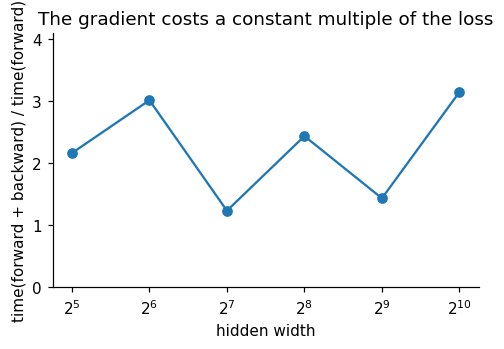

In [9]:
def loss_of_mlp(width, batch=256, d_in=64, classes=10, seed=0):
    r = np.random.default_rng(seed)
    X, labels = Tensor(r.normal(size=(batch, d_in))), r.integers(0, classes, size=batch)
    model = MLP([d_in, width, classes], rng=r)
    return model, (lambda: cross_entropy(model(X), labels))

def best_time(fn, repeats=5):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    return min(times)

widths, ratios = [32, 64, 128, 256, 512, 1024], []
for w in widths:
    model, loss = loss_of_mlp(w)
    t_forward = best_time(loss)
    t_both = best_time(lambda: loss().backward())
    ratios.append(t_both / t_forward)
    print(f"width {w:5d}: {model.num_parameters():7d} parameters, forward {1e3*t_forward:6.2f} ms, "
          f"forward+backward {1e3*t_both:6.2f} ms, ratio {t_both / t_forward:.1f}")

model, loss = loss_of_mlp(1024)
n, t_f = model.num_parameters(), best_time(loss)
print(f"\nFor the width-1024 network, finite differences would need {2 * n:,} forward passes, "
      f"about {2 * n * t_f / 60:.0f} minutes; the loss and its full gradient together take {1e3 * best_time(lambda: loss().backward()):.0f} ms.")

plt.figure(figsize=(5, 3))
plt.plot(widths, ratios, "o-")
plt.xscale("log", base=2); plt.ylim(0, max(ratios) * 1.3)
plt.xlabel("hidden width"); plt.ylabel("time(forward + backward) / time(forward)")
plt.title("The gradient costs a constant multiple of the loss"); plt.show()

## 7. Checking gradients

A gradient implementation is easy to get subtly wrong, so every operation in the engine is checked against the **central difference**

$$\frac{\partial f}{\partial x_i} \approx \frac{f(x + h e_i) - f(x - h e_i)}{2h}.$$

Its error has two sources. Taylor expansion gives a truncation error of order $h^2$, while floating-point rounding in the two evaluations of $f$ contributes about $\varepsilon/h$, where $\varepsilon \approx 10^{-16}$ is machine precision. The total is smallest near $h \approx \varepsilon^{1/3} \approx 10^{-5}$, which is visible below.

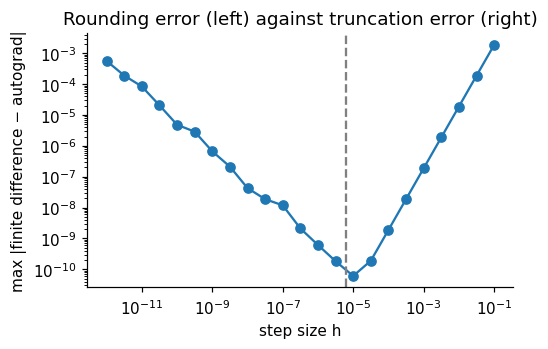

largest relative error, several operations:
  matmul + tanh          5.6e-10
  broadcast divide       2.7e-10
  softmax cross-entropy  1.4e-10
  reused tensor          7.6e-11


In [10]:
a = Tensor(rng.normal(size=(4, 3)), requires_grad=True)
g = lambda: (a.tanh() @ a.transpose()).logsumexp(axis=-1).sum()
a.grad = None; g().backward()
exact = a.grad.copy()

hs = np.logspace(-12, -1, 23)
errors = [np.abs(numerical_grad(g, a, eps=h) - exact).max() for h in hs]
plt.figure(figsize=(5, 3))
plt.loglog(hs, errors, "o-")
plt.axvline(np.finfo(float).eps ** (1 / 3), ls="--", c="gray")
plt.xlabel("step size h"); plt.ylabel("max |finite difference − autograd|")
plt.title("Rounding error (left) against truncation error (right)"); plt.show()

print("largest relative error, several operations:")
b = Tensor(rng.normal(size=(3, 5)), requires_grad=True)
checks = {
    "matmul + tanh": lambda: (a @ b).tanh().sum(),
    "broadcast divide": lambda: (a / (b.sum(axis=1, keepdims=True).transpose() ** 2 + 1.0)).sum(),
    "softmax cross-entropy": lambda: cross_entropy(a @ b, np.array([0, 4, 2, 1])),
    "reused tensor": lambda: (a * a * a).sum(),
}
for name, fn in checks.items():
    print(f"  {name:22s} {gradcheck(fn, [a, b]):.1e}")

In [11]:
try:
    import torch
    W = rng.normal(size=(5, 3)); X = rng.normal(size=(8, 5)); labels = rng.integers(0, 3, size=8)
    ours = Tensor(W, requires_grad=True)
    cross_entropy((Tensor(X) @ ours).tanh(), labels).backward()
    theirs = torch.tensor(W, requires_grad=True)
    torch.nn.functional.cross_entropy(torch.tanh(torch.tensor(X) @ theirs), torch.tensor(labels)).backward()
    print("largest difference from PyTorch's gradient:", np.abs(ours.grad - theirs.grad.numpy()).max())
except ImportError:
    print("PyTorch is not installed; skipping the comparison.")

largest difference from PyTorch's gradient: 4.85722573273506e-17


## 8. Logistic regression

Now we train a model. The data are two interleaved half-moons in the plane, with labels $y \in \{0, 1\}$. Logistic regression predicts $\Pr(y = 1 \mid x) = \sigma(w^\top x + b)$ and is fitted by minimizing the average cross-entropy.

The data are split once into **training**, **validation**, and **test** sets. Only the training set is used for fitting, the validation set for choices such as the model size, and the test set once at the very end.

In [12]:
from sklearn.datasets import make_moons, load_digits

def split(X, y, seed=0, frac=(0.6, 0.2)):
    idx = np.random.default_rng(seed).permutation(len(X))
    a, b = int(frac[0] * len(X)), int((frac[0] + frac[1]) * len(X))
    return (X[idx[:a]], y[idx[:a]]), (X[idx[a:b]], y[idx[a:b]]), (X[idx[b:]], y[idx[b:]])

X, y = make_moons(n_samples=600, noise=0.2, random_state=0)
(Xtr, ytr), (Xva, yva), (Xte, yte) = split(X, y)

def train(model, Xtr, ytr, Xva, yva, steps=400, lr=0.05, loss_fn=cross_entropy):
    opt = Adam(model.parameters(), lr=lr)
    history = []
    for step in range(steps):
        loss = loss_fn(model(Tensor(Xtr)), ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 10 == 0 or step == steps - 1:
            history.append((step, loss.item(), loss_fn(model(Tensor(Xva)), yva).item()))
    return np.array(history)

def accuracy(model, X, y):
    out = model(Tensor(X)).data
    pred = (out[:, 0] > 0).astype(int) if out.shape[1] == 1 else out.argmax(axis=1)
    return (pred == y).mean()

bce = lambda logits, y: binary_cross_entropy_with_logits(logits.reshape(-1), y)
logreg = Linear(2, 1, rng=np.random.default_rng(0))
hist_lr = train(logreg, Xtr, ytr, Xva, yva, loss_fn=bce)
print(f"logistic regression: train accuracy {accuracy(logreg, Xtr, ytr):.3f}, validation accuracy {accuracy(logreg, Xva, yva):.3f}")

logistic regression: train accuracy 0.897, validation accuracy 0.850


## 9. A two-layer network

A linear classifier can only draw a straight boundary, and the moons are not linearly separable. A network with one hidden layer of `tanh` units, $x \mapsto W_2 \tanh(W_1 x + b_1) + b_2$, can bend it. The code is the same; only the model changes.

two-layer network:   train accuracy 0.989, validation accuracy 0.975


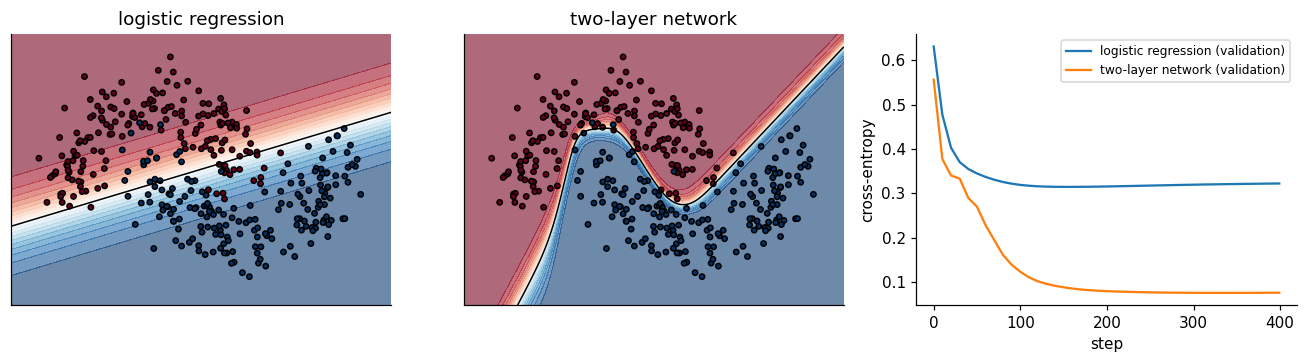

In [13]:
mlp = MLP([2, 16, 1], rng=np.random.default_rng(0))
hist_mlp = train(mlp, Xtr, ytr, Xva, yva, loss_fn=bce)
print(f"two-layer network:   train accuracy {accuracy(mlp, Xtr, ytr):.3f}, validation accuracy {accuracy(mlp, Xva, yva):.3f}")

xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.2, 1.7, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, model, name in [(axes[0], logreg, "logistic regression"), (axes[1], mlp, "two-layer network")]:
    p = model(Tensor(grid)).sigmoid().data.reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=20, cmap="RdBu", alpha=0.6)
    ax.contour(xx, yy, p, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(*Xtr.T, c=ytr, cmap="RdBu", edgecolors="k", s=12)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
for hist, name in [(hist_lr, "logistic regression"), (hist_mlp, "two-layer network")]:
    axes[2].plot(hist[:, 0], hist[:, 2], label=f"{name} (validation)")
axes[2].set_xlabel("step"); axes[2].set_ylabel("cross-entropy"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Handwritten digits

The same code trains a ten-class classifier on the $8\times 8$ digit images bundled with scikit-learn (1,797 images). The validation set chooses the hidden width; the test set is used once, for the chosen model.

In [14]:
digits = load_digits()
Xd, yd = digits.data / 16.0, digits.target
(Dtr, ltr), (Dva, lva), (Dte, lte) = split(Xd, yd)

results = {}
results["softmax regression"] = Linear(64, 10, rng=np.random.default_rng(0))
train(results["softmax regression"], Dtr, ltr, Dva, lva, steps=300)
for width in [16, 32, 64]:
    model = MLP([64, width, 10], rng=np.random.default_rng(0))
    train(model, Dtr, ltr, Dva, lva, steps=300)
    results[f"two-layer, width {width}"] = model

for name, model in results.items():
    print(f"{name:22s} {model.num_parameters():5d} parameters   "
          f"train {accuracy(model, Dtr, ltr):.3f}   validation {accuracy(model, Dva, lva):.3f}")

best = max(results, key=lambda k: accuracy(results[k], Dva, lva))
print(f"\nchosen on validation: {best}; test accuracy {accuracy(results[best], Dte, lte):.3f} (the only use of the test set)")

softmax regression       650 parameters   train 0.997   validation 0.972
two-layer, width 16     1210 parameters   train 1.000   validation 0.975
two-layer, width 32     2410 parameters   train 1.000   validation 0.981
two-layer, width 64     4810 parameters   train 1.000   validation 0.975

chosen on validation: two-layer, width 32; test accuracy 0.983 (the only use of the test set)


## What comes next

This engine is the first piece of `tinylm`, the codebase that grows into a small language model over the course. From Week 2 on, PyTorch's autograd takes over the same job, with the same interface (`requires_grad`, `backward()`, `.grad`, `zero_grad()`, `step()`), so that the models can grow.

## Exercises

1. **A new operation.** Add `softplus(x) = log(1 + e^x)` to `Tensor`, following the pattern of `exp` or `tanh`: compute the output, then write its backward rule. Use a numerically stable form. Check it with `gradcheck`, including at $x = \pm 800$.
2. **Reuse.** Explain why `backward` must *add* the contributions arriving at a tensor that is used more than once. Which test in `tests/test_autograd.py` fails if the addition becomes an assignment?
3. **Forward mode.** Implement forward-mode differentiation for scalar functions with dual numbers $a + b\varepsilon$, $\varepsilon^2 = 0$. How many passes does it need for the gradient of a function of $n$ inputs, and when is forward mode the better choice?
4. **Memory.** Reverse mode must keep every intermediate value until the backward pass reaches it. Estimate the memory of the width-1024 network in Section 6, and describe a way to trade computation for memory.
5. **Data discipline.** What goes wrong if the hidden width is chosen by test accuracy instead of validation accuracy? Simulate it: train many models with random widths and seeds, and compare the best test accuracy with the test accuracy of the model chosen on validation.